In [ ]:
import torch

In [ ]:
torch.cuda.is_available()

True

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models

In [ ]:
def display_images(image_paths, title, max_images=4):
  plt.figure(figsize=(12, 3))
  for i, image_path in enumerate(image_paths[:max_images]):
    img = plt.imread(image_path)
    plt.subplot(1, max_images, i+1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
  plt.show()

In [ ]:
categories = ['Train Clean', 'Train Messy', 'Val Clean', 'Val Messy', 'Test Clean', 'Test Messy']

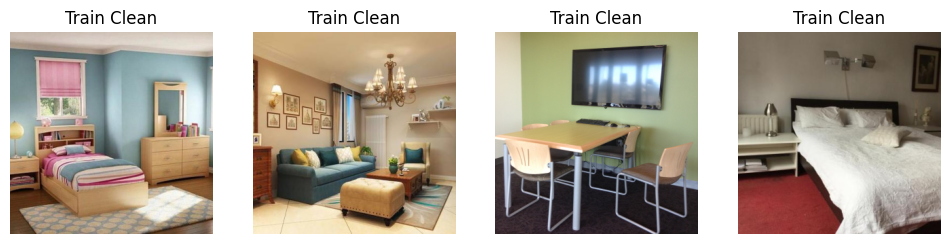

Train Clean 총 이미지 수: 96


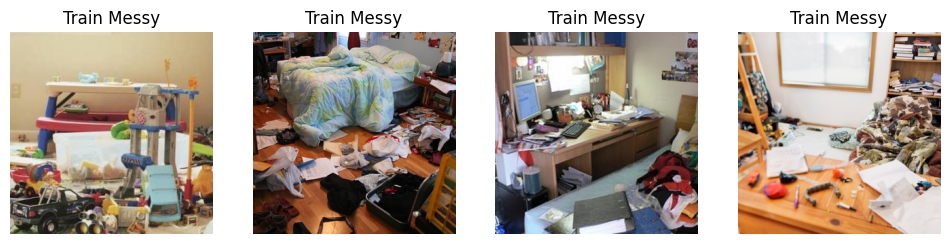

Train Messy 총 이미지 수: 96


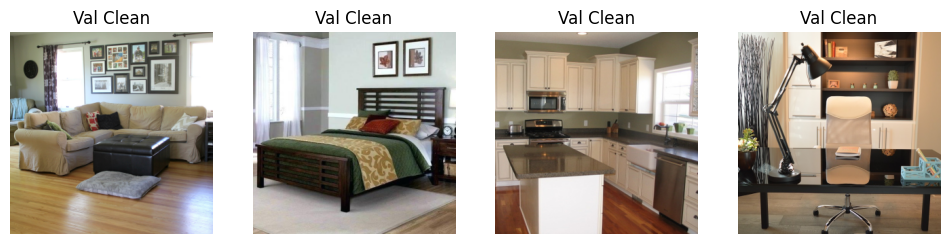

Val Clean 총 이미지 수: 10


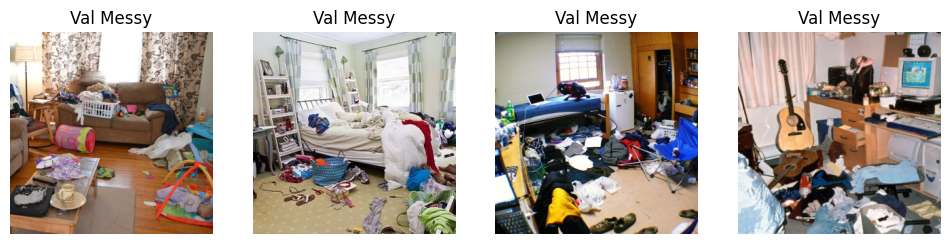

Val Messy 총 이미지 수: 10


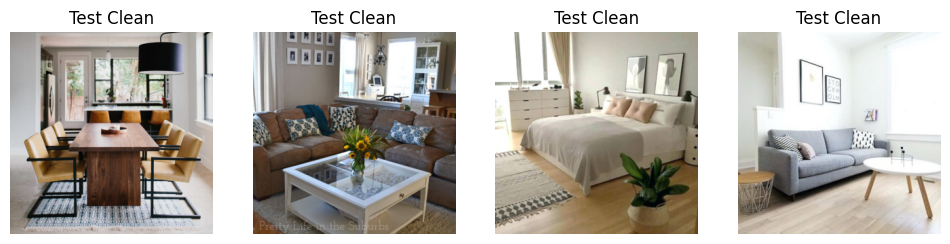

Test Clean 총 이미지 수: 5


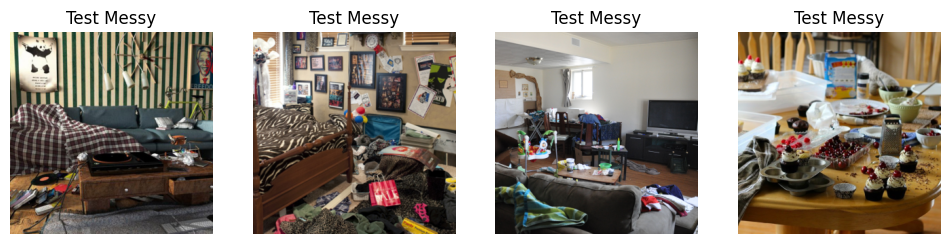

Test Messy 총 이미지 수: 5


In [ ]:
for category in categories:
  image_paths = glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/{category.lower().replace(' ', '/')}/*')
  display_images(image_paths, category)
  print(f"{category} 총 이미지 수: {len(image_paths)}")



In [ ]:
glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/{category.lower().replace(' ', '/')}/*')

['/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/test/messy/4.png',
 '/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/test/messy/8.png',
 '/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/test/messy/5.png',
 '/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/test/messy/7.png',
 '/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/test/messy/2.png']

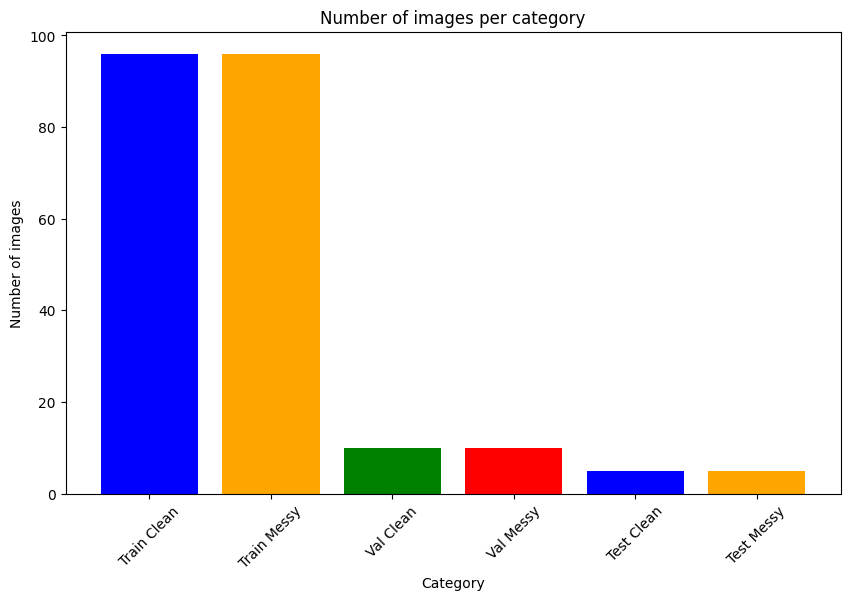

In [ ]:
  plt.figure(figsize=(10, 6))
  plt.bar(categories, [len(glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/{category.lower().replace(' ', '/')}/*')) for category in categories], color=['blue', 'orange', 'green', 'red'])
  plt.title('Number of images per category')
  plt.xlabel('Category')
  plt.ylabel('Number of images')
  plt.xticks(rotation=45)
  plt.show()

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = ImageFolder('/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/train', transform=transform)
val_dataset = ImageFolder('/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/val', transform=transform)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

In [ ]:
net = models.alexnet(pretrained=True)
net

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 141MB/s]


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
for param in net.parameters():
  param.requires_grad = False

In [ ]:
net.classifier[6] = nn.Linear(4096, 2)

net.classifier[5].requires_grad = True
net.classifier[6].requires_grad = True

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.0001)

In [ ]:
def calculate_accuracy(loader, model):
  model.eval()
  correct = 0
  total = 0
  with torch.no_grad():
    for data in loader:
      images, labels = data
      outputs = model(images)
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()
  return 100 * correct / total

In [ ]:
train_losses = []
val_losses = []
val_accuracies = []

num_epochs = 5
for epoch in range(num_epochs):
  net.train()
  running_loss = 0
  for i, data in enumerate(train_loader):
    inputs, labels = data
    optimizer.zero_grad()
    outputs = net(inputs)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  train_loss = running_loss / len(train_loader)
  train_losses.append(train_loss)

  val_loss = 0.0
  net.eval()
  with torch.no_grad():
    for inputs, labels in val_loader:
      outputs = net(inputs)
      loss = criterion(outputs, labels)
      val_loss += loss.item()
  val_loss /= len(val_loader)
  val_losses.append(val_loss)

  val_accuracy = calculate_accuracy(val_loader, net)
  val_accuracies.append(val_accuracy)

  print(f'Epoch {epoch + 1}, Train Loss: {train_loss: .6f}, Validation Loss: {val_loss: .6f}, Validation Accuracy: {val_accuracy: .2f}%')

print('Finished Training')

Epoch 1, Train Loss:  0.578125, Validation Loss:  0.344313, Validation Accuracy:  95.00%
Epoch 2, Train Loss:  0.330461, Validation Loss:  0.203945, Validation Accuracy:  100.00%
Epoch 3, Train Loss:  0.248228, Validation Loss:  0.169391, Validation Accuracy:  100.00%
Epoch 4, Train Loss:  0.203969, Validation Loss:  0.133158, Validation Accuracy:  100.00%
Epoch 5, Train Loss:  0.177469, Validation Loss:  0.120361, Validation Accuracy:  100.00%
Finished Training


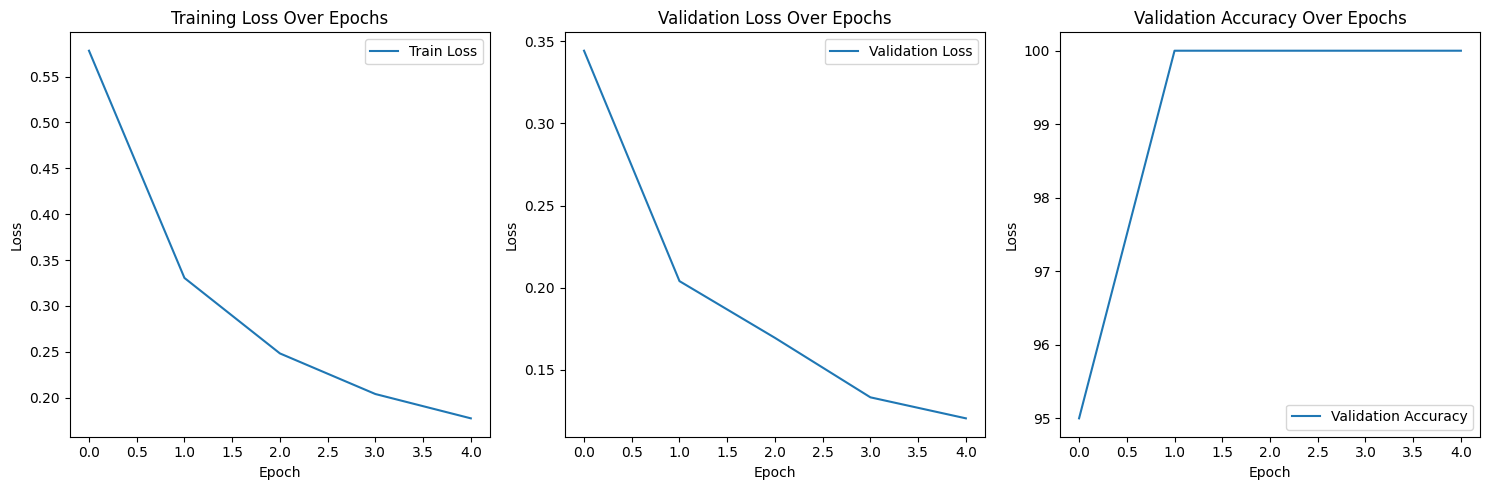

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(train_losses, label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
def load_and_transform_image(image_path, transforms):
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0)

In [ ]:
class_folders = {
    'clean': '/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/val/clean',
    'messy': '/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Room Dataset/val/messy'
}

plt.figure(figsize=(20, 8))
counter = 1

for class_name, folder_path in class_folders.items():
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5]

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, transform)

    net.eval()

    with torch.no_grad():
      outputs = net(image)
      _, predicted = torch.max(outputs, 1)
    prediction = 'clean' if predicted.item() == 0 else 'messy'

    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path))
    plt.title(f'True: {class_name}, Pred: {prediction}')
    plt.axis('off')

    counter += 1
plt.tight_layout()
plt.show()



Output hidden; open in https://colab.research.google.com to view.